# Book Recommendation

In [1]:
#Import packages
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
# Load dataset
users = pd.read_csv('data/Users.csv')
books = pd.read_csv('data/Books.csv')
ratings = pd.read_csv('data/Ratings.csv')

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_29724\834789582.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('data/Books.csv')


In [3]:
# Data standardization
users.columns = users.columns.str.lower().str.replace('-','_')
books.columns = books.columns.str.lower().str.replace('-','_')
ratings.columns = ratings.columns.str.lower().str.replace('-','_')

In [4]:
# Identifying dimensions in each dataset
print(f"Users shape: {users.shape}")
print(f"Books shape: {books.shape}")
print(f"Ratings shape: {ratings.shape}")

Users shape: (278858, 3)
Books shape: (271360, 8)
Ratings shape: (1048575, 3)


In [5]:
# Checking missing values
print("Users:\n", users.isnull().sum())
print("Books:\n",books.isnull().sum())
print("Ratings:\n",ratings.isnull().sum())

Users:
 user_id          0
location         0
age         110762
dtype: int64
Books:
 isbn                   0
book_title             0
book_author            2
year_of_publication    0
publisher              2
image_url_s            0
image_url_m            0
image_url_l            3
dtype: int64
Ratings:
 user_id        0
isbn           0
book_rating    0
dtype: int64


# Data Visualization

In [6]:
explicit_ratings = ratings[ratings['book_rating'] > 0].copy()
df_merged = explicit_ratings.merge(books, on='isbn', how='inner')
user_counts = df_merged['user_id'].value_counts()
book_counts = df_merged['isbn'].value_counts()
filtered_df = df_merged[ df_merged['user_id'].isin(user_counts[user_counts >=10].index) &
    df_merged['isbn'].isin(book_counts[book_counts >= 20].index)
    ]

In [10]:
num_ratings = filtered_df.groupby('book_title')['book_rating'].count().reset_index()
num_ratings.columns = ['book_title', 'num_ratings']
avg_ratings = filtered_df.groupby('book_title')['book_rating'].mean().reset_index()
avg_ratings.columns = ['book_title','avg_rating']

In [11]:
popular_df = pd.merge(num_ratings, avg_ratings, on='book_title')
popular_df = popular_df[popular_df['num_ratings'] >=20].sort_values('avg_rating',ascending=False)

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_29724\3638712762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings, x='book_rating',palette='viridis')


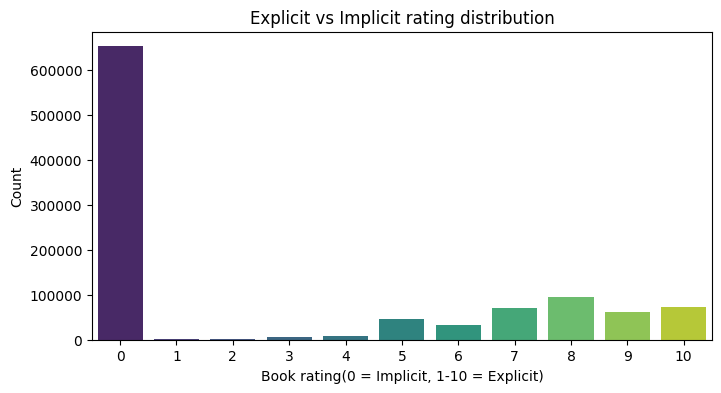

In [12]:
# Count plot
plt.figure(figsize=(8,4))
sns.countplot(data=ratings, x='book_rating',palette='viridis')
plt.title('Explicit vs Implicit rating distribution')
plt.xlabel('Book rating(0 = Implicit, 1-10 = Explicit)')
plt.ylabel('Count')
plt.show()

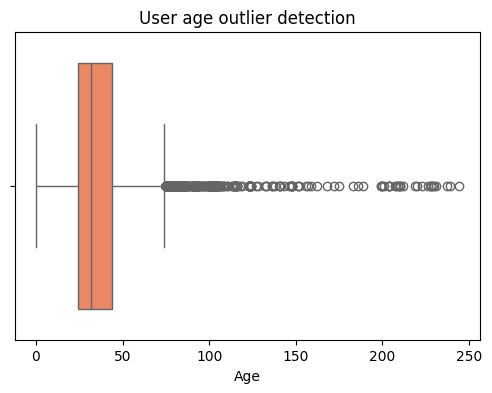

In [13]:
# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x=users['age'],color='coral')
plt.title('User age outlier detection')
plt.xlabel('Age')
plt.show()

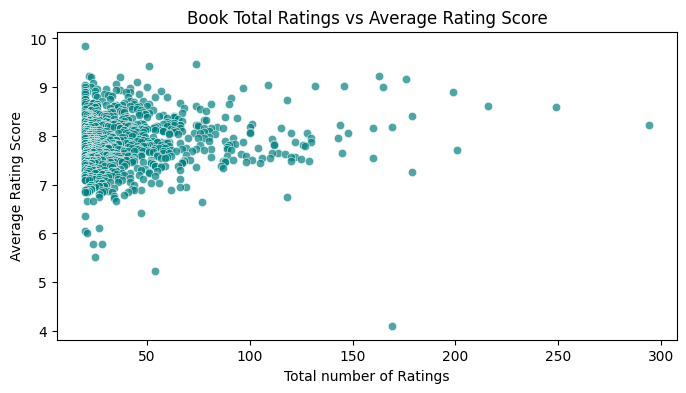

In [14]:
# Scatter plot
plt.figure(figsize=(8,4))
sns.scatterplot(data=popular_df,x='num_ratings',y='avg_rating',color='teal',alpha=0.7)
plt.title('Book Total Ratings vs Average Rating Score')
plt.xlabel('Total number of Ratings')
plt.ylabel('Average Rating Score')
plt.show()

In [15]:
# 3. FEATURE ENGINEERING & DATA CLEANING
# Outlier Removal & Imputation for Age
users.loc[(users['age'] < 5) | (users['age'] > 90), 'age'] = np.nan
users['age'] = users['age'].fillna(users['age'].median())

In [ ]:
# Engineered Feature: Age Bins
users['age_group'] = pd.cut(
    users['age'],
    bins=[0, 18, 35, 50, 65, 100],
    labels=['Teens', 'Young Adult', 'Adult', 'Middle Aged', 'Senior']
)

In [17]:
# Engineered Feature: Location Parsing (City, State, Country)
def parse_location(loc_str):
    if not isinstance(loc_str, str):
        return np.nan, np.nan, np.nan
    parts = [p.strip() for p in loc_str.split(',')]
    city = parts[0] if len(parts) > 0 else np.nan
    state = parts[1] if len(parts) > 1 else np.nan
    country = parts[-1] if len(parts) > 2 else (parts[1] if len(parts) == 2 else np.nan)
    return city, state, country

In [18]:
loc_split = users['location'].str.split(',', expand=True)
users['city'] = loc_split[0].str.strip() if 0 in loc_split else np.nan
users['state'] = loc_split[1].str.strip() if 1 in loc_split else np.nan
users['country'] = loc_split.iloc[:,-1].str.strip() if loc_split.shape[1] > 2 else np.nan
users.drop(columns=['location'], inplace=True)

In [19]:
# Books Processing
# Drop non-essential image URL columns if present
img_cols = [c for c in books.columns if 'image' in c or 'url' in c]
books.drop(columns=img_cols, inplace=True, errors='ignore')

In [20]:
# Clean text fields
books['book_title'] = books['book_title'].astype(str).str.strip()
books['book_author'] = books['book_author'].astype(str).str.strip()

In [21]:
# Ratings Processing & Filtering
# Separate explicit ratings (1-10) from implicit (0)
explicit_ratings = ratings[ratings['book_rating'] > 0].copy()

In [22]:
# Calculate interaction counts
user_counts = explicit_ratings['user_id'].value_counts()
book_counts = explicit_ratings['isbn'].value_counts()

In [23]:
# Engineered Aggregates
explicit_ratings['user_total_ratings'] = explicit_ratings['user_id'].map(user_counts)
explicit_ratings['book_total_ratings'] = explicit_ratings['isbn'].map(book_counts)

In [24]:
# Merge datasets
df_merged = explicit_ratings.merge(books, on='isbn', how='inner')
df_merged = df_merged.merge(users, on='user_id', how='left')

In [25]:
# Filter for active users (>= 10 ratings) and popular books (>= 20 ratings) to reduce matrix sparsity
filtered_df = df_merged[
    (df_merged['user_total_ratings'] >= 10) & (df_merged['book_total_ratings'] >= 20)
]

In [26]:
# # EXPORT PROCESSED DATASETS
# filtered_df.to_csv('cleaned_ratings.csv', index=False)
# users.to_csv('cleaned_users.csv', index=False)
# books.to_csv('cleaned_books.csv', index=False)
# print(f"Filtered Dataset Shape: {filtered_df.shape}")
# print("Cleaned datasets saved successfully as 'cleaned_ratings.csv', 'cleaned_users.csv', and 'cleaned_books.csv'.")

# 4. Model Building
Five models spanning the main recommender paradigms: a non-personalized baseline, two rating-based collaborative-filtering approaches (item- and user-based), a content-based model built from the engineered book features, and a model-based (matrix factorization) approach. All five are scored on the same train/test split so they're directly comparable.

## 4.0 Train/Test Split
Split once up front — every model below is fit/evaluated on the same split.

In [27]:
train_df, test_df = train_test_split(filtered_df, test_size=0.2, random_state=42)
global_mean_rating = train_df['book_rating'].mean()
print(f"Train: {train_df.shape}, Test: {test_df.shape}, Global mean rating: {global_mean_rating:.3f}")

Train: (40688, 14), Test: (10172, 14), Global mean rating: 7.882


## 4.1 Model 1 — Popularity-Based Recommender (Baseline)
Non-personalized: every user gets the same recommendation. Predicted rating for evaluation = the book's average rating in the training set.

In [28]:
train_book_avg = train_df.groupby('book_title')['book_rating'].mean()

def popularity_recommender(top_n=10):
    return popular_df.head(top_n)[['book_title', 'num_ratings', 'avg_rating']].reset_index(drop=True)

def predict_rating_popularity(book_title):
    return train_book_avg.get(book_title, global_mean_rating)

popularity_recommender(10)

,book_title,num_ratings,avg_rating
0,Harry Potter and the Chamber of Secrets Postca...,20,9.850000
1,"The Two Towers (The Lord of the Rings, Part 2)",74,9.472973
2,"The Return of the King (The Lord of the Rings,...",51,9.431373
3,The Cat in the Hat,22,9.227273
4,Harry Potter and the Goblet of Fire (Book 4),163,9.220859
5,Weirdos From Another Planet!,23,9.217391
6,Charlotte's Web (Trophy Newbery),37,9.216216
7,Harry Potter and the Prisoner of Azkaban (Book 3),176,9.159091
8,The Little Prince,45,9.111111
9,The Lord of the Rings (Movie Art Cover),24,9.083333


## 4.2 Model 2 — Item-Based Collaborative Filtering (Cosine Similarity)
Recommend books similar to a given title; predict a rating as the similarity-weighted average of the user's own ratings for the most similar books they've already rated.

In [29]:
# Full-data matrix (for production recommend_books) and train-only matrix (for fair evaluation)
pivot_table = filtered_df.pivot_table(index='book_title', columns='user_id', values='book_rating').fillna(0)
book_similarity_df = pd.DataFrame(cosine_similarity(pivot_table), index=pivot_table.index, columns=pivot_table.index)

train_item_pivot = train_df.pivot_table(index='book_title', columns='user_id', values='book_rating').fillna(0)
train_item_similarity_df = pd.DataFrame(
    cosine_similarity(train_item_pivot), index=train_item_pivot.index, columns=train_item_pivot.index
)

def recommend_books(book_title, top_n=5):
    if book_title not in book_similarity_df.index:
        return f"'{book_title}' not found in the filtered dataset."
    scores = book_similarity_df[book_title].drop(book_title, errors='ignore')
    return scores.sort_values(ascending=False).head(top_n)

def predict_rating_item_cf(user_id, book_title, k=10):
    if book_title not in train_item_similarity_df.index or user_id not in train_item_pivot.columns:
        return global_mean_rating
    user_ratings = train_item_pivot[user_id]
    rated_books = user_ratings[user_ratings > 0]
    if rated_books.empty:
        return global_mean_rating
    sims = train_item_similarity_df.loc[book_title, rated_books.index]
    top_k = sims.sort_values(ascending=False).head(k)
    top_k = top_k[top_k > 0]
    if top_k.empty:
        return global_mean_rating
    return (top_k * rated_books[top_k.index]).sum() / top_k.sum()

## 4.3 Model 3 — User-Based Collaborative Filtering (Cosine Similarity)
Find users with similar taste, then predict/recommend based on what they rated highly.

In [30]:
user_pivot = filtered_df.pivot_table(index='user_id', columns='book_title', values='book_rating').fillna(0)
user_similarity_df = pd.DataFrame(cosine_similarity(user_pivot), index=user_pivot.index, columns=user_pivot.index)

train_user_pivot = train_df.pivot_table(index='user_id', columns='book_title', values='book_rating').fillna(0)
train_user_similarity_df = pd.DataFrame(
    cosine_similarity(train_user_pivot), index=train_user_pivot.index, columns=train_user_pivot.index
)

def recommend_for_user(user_id, top_n=5):
    if user_id not in user_similarity_df.index:
        return f"User {user_id} not found in the filtered dataset."
    top_similar_users = user_similarity_df[user_id].drop(user_id, errors='ignore').sort_values(ascending=False).head(10).index
    mean_scores = user_pivot.loc[top_similar_users].mean(axis=0)
    mean_scores = mean_scores[user_pivot.loc[user_id] == 0]  # only books this user hasn't rated
    return mean_scores.sort_values(ascending=False).head(top_n)

def predict_rating_user_cf(user_id, book_title, k=10):
    if user_id not in train_user_similarity_df.index or book_title not in train_user_pivot.columns:
        return global_mean_rating
    book_ratings = train_user_pivot[book_title]
    raters = book_ratings[book_ratings > 0]
    if raters.empty:
        return global_mean_rating
    sims = train_user_similarity_df.loc[user_id, raters.index]
    top_k = sims.sort_values(ascending=False).head(k)
    top_k = top_k[top_k > 0]
    if top_k.empty:
        return global_mean_rating
    return (top_k * raters[top_k.index]).sum() / top_k.sum()

## 4.4 Model 4 — Content-Based Filtering (TF-IDF on Title + Author)
Uses the engineered book features directly (title, author) rather than the rating matrix — this is the model that most literally satisfies the brief's "generate features and use them to recommend books" objective.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Only books that actually appear in the filtered ratings (a few thousand, not the full ~270k catalogue)
books_content = (
    books[books['book_title'].isin(filtered_df['book_title'].unique())]
    .drop_duplicates(subset='book_title')
    .reset_index(drop=True)
)
books_content['content'] = books_content['book_title'].astype(str) + ' ' + books_content['book_author'].astype(str)
print("Books in content model:", len(books_content))

tfidf_matrix = TfidfVectorizer(stop_words='english').fit_transform(books_content['content'])
content_similarity_df = pd.DataFrame(
    cosine_similarity(tfidf_matrix).astype('float32'),
    index=books_content['book_title'], columns=books_content['book_title']
)

def recommend_by_content(book_title, top_n=5):
    if book_title not in content_similarity_df.index:
        return f"'{book_title}' not found."
    scores = content_similarity_df[book_title].drop(book_title, errors='ignore')
    return scores.sort_values(ascending=False).head(top_n)

def predict_rating_content(user_id, book_title, k=10):
    if book_title not in content_similarity_df.index or user_id not in train_item_pivot.columns:
        return global_mean_rating
    user_ratings = train_item_pivot[user_id]
    rated_books = user_ratings[user_ratings > 0]
    rated_books = rated_books[rated_books.index.isin(content_similarity_df.columns)]
    if rated_books.empty:
        return global_mean_rating
    sims = content_similarity_df.loc[book_title, rated_books.index]
    top_k = sims.sort_values(ascending=False).head(k)
    top_k = top_k[top_k > 0]
    if top_k.empty:
        return global_mean_rating
    return (top_k * rated_books[top_k.index]).sum() / top_k.sum()

Books in content model: 1678


## 4.5 Model 5 — Matrix Factorization (Truncated SVD)
Model-based collaborative filtering: decompose the train user×book matrix into latent factors and reconstruct predicted ratings from them.

In [32]:
from sklearn.decomposition import TruncatedSVD

svd_pivot = train_user_pivot  # user x book, train only
n_components = max(2, min(20, min(svd_pivot.shape) - 1))
svd_model = TruncatedSVD(n_components=n_components, random_state=42)
latent = svd_model.fit_transform(svd_pivot)
svd_reconstructed = pd.DataFrame(
    np.dot(latent, svd_model.components_), index=svd_pivot.index, columns=svd_pivot.columns
)

def predict_rating_svd(user_id, book_title):
    if user_id not in svd_reconstructed.index or book_title not in svd_reconstructed.columns:
        return global_mean_rating
    return svd_reconstructed.loc[user_id, book_title]

def recommend_svd(user_id, top_n=5):
    if user_id not in svd_reconstructed.index:
        return f"User {user_id} not found in the filtered dataset."
    already_rated = svd_pivot.loc[user_id]
    scores = svd_reconstructed.loc[user_id][already_rated == 0]
    return scores.sort_values(ascending=False).head(top_n)

## 4.6 Model Evaluation & Comparison (RMSE / MAE)
Same test set, same metric, for all five models — pick the winner from this table.

In [33]:
def evaluate(name, predict_fn, needs_user=True):
    if needs_user:
        preds = test_df.apply(lambda r: predict_fn(r['user_id'], r['book_title']), axis=1)
    else:
        preds = test_df['book_title'].map(predict_fn)
    rmse = np.sqrt(mean_squared_error(test_df['book_rating'], preds))
    mae = mean_absolute_error(test_df['book_rating'], preds)
    return {'model': name, 'rmse': rmse, 'mae': mae}

results = [
    evaluate('Popularity (baseline)', predict_rating_popularity, needs_user=False),
    evaluate('Item-Based CF', predict_rating_item_cf),
    evaluate('User-Based CF', predict_rating_user_cf),
    evaluate('Content-Based (TF-IDF)', predict_rating_content),
    evaluate('Matrix Factorization (SVD)', predict_rating_svd),
]

results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)
print(f"\nBest model: {results_df.iloc[0]['model']}")

                        model      rmse       mae
0               Item-Based CF  1.690949  1.225371
1      Content-Based (TF-IDF)  1.722783  1.243252
2       Popularity (baseline)  1.723625  1.349593
3               User-Based CF  1.861519  1.438546
4  Matrix Factorization (SVD)  7.674095  7.400600

Best model: Item-Based CF


## 4.7 Save Model Artifacts for Deployment
Pickle everything the Flask/Streamlit app needs at inference time.

In [34]:
with open('book_similarity.pkl', 'wb') as f:
    pickle.dump(book_similarity_df, f)
with open('user_similarity.pkl', 'wb') as f:
    pickle.dump(user_similarity_df, f)
with open('content_similarity.pkl', 'wb') as f:
    pickle.dump(content_similarity_df, f)
with open('svd_model.pkl', 'wb') as f:
    pickle.dump({'model': svd_model, 'reconstructed': svd_reconstructed}, f)
with open('pivot_table.pkl', 'wb') as f:
    pickle.dump(pivot_table, f)
with open('popular_books.pkl', 'wb') as f:
    pickle.dump(popular_df, f)
with open('model_comparison.pkl', 'wb') as f:
    pickle.dump(results_df, f)

print("Saved 7 artifacts:", "book_similarity.pkl, user_similarity.pkl, content_similarity.pkl,",
      "svd_model.pkl, pivot_table.pkl, popular_books.pkl, model_comparison.pkl")

Saved 7 artifacts: book_similarity.pkl, user_similarity.pkl, content_similarity.pkl, svd_model.pkl, pivot_table.pkl, popular_books.pkl, model_comparison.pkl
